In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
from scipy.stats import spearmanr
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [2]:
import itertools
from Bio import SeqIO

In [3]:
predicted_dir = Path('predicted')
result_files = list(predicted_dir.rglob("pred.csv"))
print(f"Found {len(result_files)} result files.")

Found 2872 result files.


In [4]:
a_types       = ["none", "single", "position-specific", "context-specific"]
a_inits       = [0.1, -1.0]
combined_ways = ["logits", "scores"]
train_modes   = ["full", "a_only"]

combinations = list(itertools.product(a_types, a_inits, combined_ways, train_modes))

In [5]:
len(combinations)

32

In [6]:
base_dir = Path("/work/yunan/PsiFit/data/proteingym")
datasets = [d.name for d in base_dir.iterdir() if d.is_dir()]

In [7]:
data = []

for dataset in datasets:
    fasta_path = base_dir / dataset / "wildtype.fasta"
    if fasta_path.exists():
        try:
            record = next(SeqIO.parse(fasta_path, "fasta"))
            seq = str(record.seq)
            length = len(seq)
            data.append({'dms_id': dataset, 'seq_length': length})
        except Exception as e:
            print(f"Error processing {fasta_path}: {e}")
            
df = pd.DataFrame(data)
df = df[~df['dms_id'].str.contains("Tsuboyama")]
df.sort_values(by='seq_length', ascending=True, inplace=True)

In [8]:
short_df = df[df['seq_length'] <= 1022].copy().reset_index(drop=True)

In [9]:
short_df.shape

(116, 2)

In [10]:
short_df.tail(29)

,dms_id,seq_length
87,CD19_HUMAN_Klesmith_2019_FMC_singles,556
88,A0A2Z5U3Z0_9INFA_Wu_2014,565
89,A0A2Z5U3Z0_9INFA_Doud_2016,565
90,C6KNH7_9INFA_Lee_2018,566
91,Q837P5_ENTFA_Meier_2023,571
92,SHOC2_HUMAN_Kwon_2022,582
93,Q837P4_ENTFA_Meier_2023,589
94,PPM1D_HUMAN_Miller_2022,605
95,ANCSZ_Hobbs_2022,627
96,SC6A4_HUMAN_Young_2021,630


In [11]:
116*31

3596

In [12]:
full_affected = [
    ("single",  0.1,  "logits", "full"),
    ("single",  -1.0, "logits", "full"),
    ("none",    0.1,  "scores", "full"),
    ("none",    -1.0, "scores", "full"),
]
a_only_affected = list(itertools.product(
    ["single", "position-specific", "context-specific"],
    [0.1, -1.0],
    ["logits", "scores"],
    ["a_only"],
))
filtered_combinations = full_affected + a_only_affected

In [13]:
filtered_combinations

[('single', 0.1, 'logits', 'full'),
 ('single', -1.0, 'logits', 'full'),
 ('none', 0.1, 'scores', 'full'),
 ('none', -1.0, 'scores', 'full'),
 ('single', 0.1, 'logits', 'a_only'),
 ('single', 0.1, 'scores', 'a_only'),
 ('single', -1.0, 'logits', 'a_only'),
 ('single', -1.0, 'scores', 'a_only'),
 ('position-specific', 0.1, 'logits', 'a_only'),
 ('position-specific', 0.1, 'scores', 'a_only'),
 ('position-specific', -1.0, 'logits', 'a_only'),
 ('position-specific', -1.0, 'scores', 'a_only'),
 ('context-specific', 0.1, 'logits', 'a_only'),
 ('context-specific', 0.1, 'scores', 'a_only'),
 ('context-specific', -1.0, 'logits', 'a_only'),
 ('context-specific', -1.0, 'scores', 'a_only')]

In [12]:
data = []
for file in tqdm(result_files):
    parts = file.parts
    dataset = parts[1]
    folder_name = parts[2]
    
    try:
        params = folder_name.split("_")
        if params[0].startswith("shot"):
            shot         = int(params[0].replace("shot", ""))
            model_seed   = params[1].replace("seed", "")
            a_type       = params[2].replace("mode", "")
            a_init       = params[3].replace("ainit", "")
            combined_way = params[4].replace("combined", "")
            train_mode   = params[5].replace("trainmode", "")
        else:
            shot         = 96
            model_seed   = params[0].replace("seed", "")
            a_type       = params[1].replace("mode", "")
            a_init       = params[2].replace("ainit", "")
            combined_way = params[3].replace("combined", "")
            train_mode   = params[4].replace("trainmode", "")
        # print(f"{folder_name}")
        
        df = pd.read_csv(file)
        
        if "1" in df.columns and "y_true" in df.columns:
            sr = spearmanr(df["1"], df["y_true"]).correlation
        else:
            sr = np.nan
            
        data.append({
            "dataset": dataset,
            "shot": shot,
            "a_type": a_type,
            "a_init": a_init,
            "combined_way": combined_way,
            "train_mode": train_mode,
            "spearman": sr,
            "num_mutations": len(df)
        })
    except:
        print(f"Skipping malformed folder:{dataset}{folder_name}")
        continue

summary = pd.DataFrame(data)
print("summary type:", summary.shape)
summary.head()

 62%|██████▏   | 1257/2013 [00:07<00:03, 208.37it/s]

Skipping malformed folder:IF1_ECOLI_Kelsic_2016seed1_modecontext-specific_ainit0.1_combinedscores
Skipping malformed folder:IF1_ECOLI_Kelsic_2016seed1_modecontext-specific_ainit-1.0_combinedscores
Skipping malformed folder:IF1_ECOLI_Kelsic_2016seed1_modesingle_ainit-1.0_combinedlogits
Skipping malformed folder:IF1_ECOLI_Kelsic_2016seed1_modesingle_ainit0.1_combinedlogits
Skipping malformed folder:IF1_ECOLI_Kelsic_2016seed1_modesingle_ainit-1.0_combinedscores
Skipping malformed folder:IF1_ECOLI_Kelsic_2016seed1_modesingle_ainit0.1_combinedscores
Skipping malformed folder:IF1_ECOLI_Kelsic_2016seed1_modecontext-specific_ainit0.1_combinedlogits
Skipping malformed folder:IF1_ECOLI_Kelsic_2016seed1_modeposition-specific_ainit-1.0_combinedscores


100%|██████████| 2013/2013 [00:11<00:00, 177.64it/s]

summary type: (2005, 8)


,dataset,shot,a_type,a_init,combined_way,train_mode,spearman,num_mutations
0,GDIA_HUMAN_Silverstein_2021,96,context-specific,-1.0,scores,a,0.444432,234
1,GDIA_HUMAN_Silverstein_2021,96,position-specific,-1.0,scores,full,0.481679,232
2,GDIA_HUMAN_Silverstein_2021,96,position-specific,0.1,logits,full,0.459531,232
3,GDIA_HUMAN_Silverstein_2021,96,context-specific,0.1,logits,full,0.447250,232
4,GDIA_HUMAN_Silverstein_2021,96,position-specific,0.1,scores,full,0.459796,232


In [16]:
summary_sorted = summary.sort_values(["dataset", "spearman"], ascending=[True, False])
summary_sorted.head()

,dataset,shot,a_type,a_init,combined_way,train_mode,spearman,num_mutations
1954,A0A140D2T1_ZIKV_Sourisseau_2019,96,position-specific,-1.0,scores,full,0.158353,1920
1968,A0A140D2T1_ZIKV_Sourisseau_2019,96,single,-1.0,scores,full,0.158337,1920
1975,A0A140D2T1_ZIKV_Sourisseau_2019,96,single,-1.0,scores,a,0.147890,1920
1957,A0A140D2T1_ZIKV_Sourisseau_2019,96,position-specific,-1.0,scores,a,0.147864,1920
1969,A0A140D2T1_ZIKV_Sourisseau_2019,96,position-specific,-1.0,logits,full,0.147645,1920


In [17]:
best_per_dataset = summary_sorted.groupby("dataset").first().reset_index()

In [18]:
print("=== Best configuration per dataset ===")
display(best_per_dataset[['dataset', "shot", 'a_type', 'a_init', 'combined_way', 'train_mode', 'spearman']])

=== Best configuration per dataset ===


,dataset,shot,a_type,a_init,combined_way,train_mode,spearman
0,A0A140D2T1_ZIKV_Sourisseau_2019,96,position-specific,-1.0,scores,full,0.158353
1,A0A192B1T2_9HIV1_Haddox_2018,96,position-specific,-1.0,logits,a,0.617385
2,A0A1I9GEU1_NEIME_Kennouche_2019,96,context-specific,0.1,scores,a,0.078779
3,A0A247D711_LISMN_Stadelmann_2021,96,single,-1.0,scores,a,0.429958
4,A0A2Z5U3Z0_9INFA_Doud_2016,96,position-specific,-1.0,logits,a,0.613665
...,...,...,...,...,...,...,...
111,TRPC_SACS2_Chan_2017,64,context-specific,-1.0,scores,a,0.620628
112,TRPC_THEMA_Chan_2017,96,position-specific,0.1,scores,a,0.623730
113,UBC9_HUMAN_Weile_2017,96,single,0.1,logits,full,0.600888
114,VKOR1_HUMAN_Chiasson_2020_abundance,96,position-specific,-1.0,scores,a,0.616787


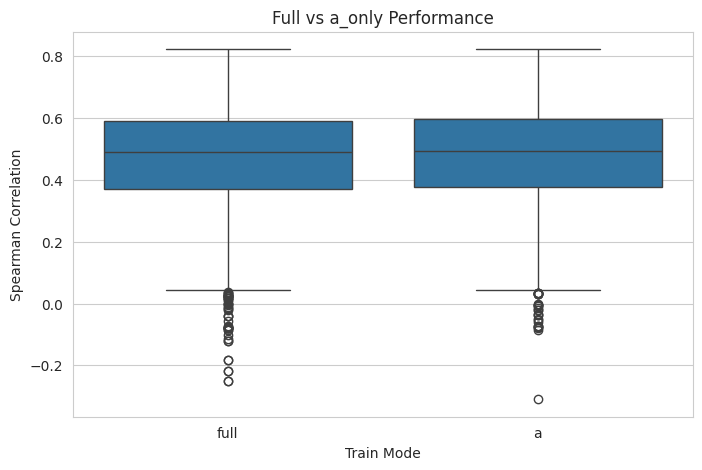

In [15]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=summary['train_mode'], y=summary['spearman'])
plt.title('Full vs a_only Performance')
plt.xlabel('Train Mode')
plt.ylabel('Spearman Correlation')
plt.show()

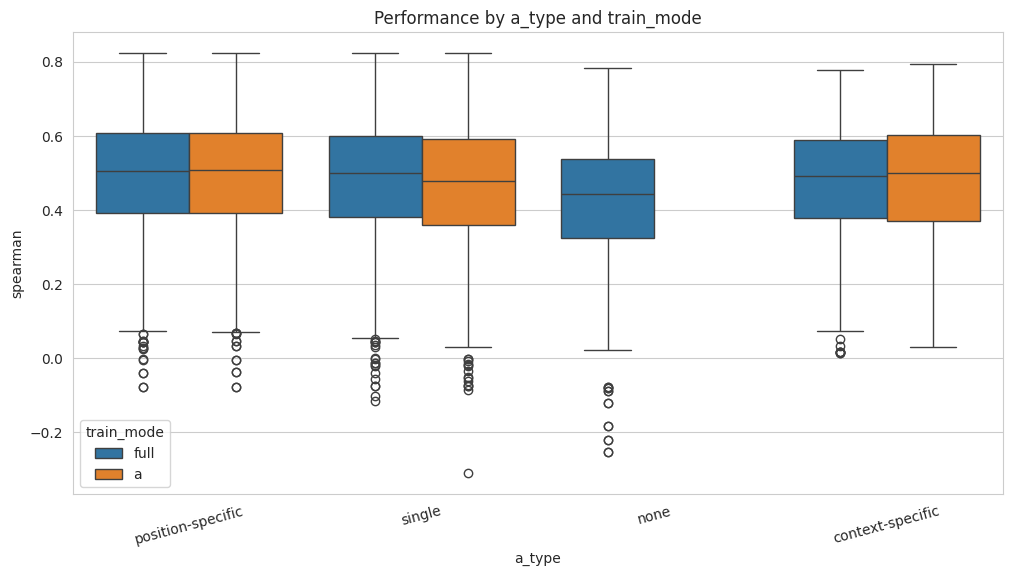

In [16]:
plt.figure()
sns.boxplot(x=summary['a_type'], y=summary['spearman'], hue=summary['train_mode'])
plt.title('Performance by a_type and train_mode')
plt.xticks(rotation=15)
plt.show()

In [18]:
temp_list = summary[(summary["a_type"]== "none") & (summary["spearman"] <= 0)]["dataset"].unique().tolist()

In [19]:
summary[summary["dataset"].isin(temp_list)]

,dataset,a_type,a_init,combined_way,train_mode,spearman,num_mutations
26,R1AB_SARS2_Flynn_2022,position-specific,-1.0,scores,full,0.400838,1152
27,R1AB_SARS2_Flynn_2022,context-specific,-1.0,scores,a,0.250516,1152
28,R1AB_SARS2_Flynn_2022,single,0.1,logits,a,-0.020870,1152
29,R1AB_SARS2_Flynn_2022,position-specific,-1.0,scores,a,0.393115,1152
30,R1AB_SARS2_Flynn_2022,single,-1.0,logits,a,0.030712,1152
...,...,...,...,...,...,...,...
1994,A0A140D2T1_ZIKV_Sourisseau_2019,single,-1.0,scores,a,0.147890,1920
1995,A0A140D2T1_ZIKV_Sourisseau_2019,single,0.1,logits,full,-0.074081,1920
1996,A0A140D2T1_ZIKV_Sourisseau_2019,position-specific,0.1,scores,a,-0.003828,1920
1997,A0A140D2T1_ZIKV_Sourisseau_2019,none,-1.0,scores,full,-0.086885,1920


In [20]:
none_negative = summary[(summary['a_type'] == 'none') & (summary['spearman'] < 0)]['dataset'].unique()

context_positive = summary[(summary['a_type'] == 'context-specific') & (summary['spearman'] > 0)]['dataset'].unique()

matching_datasets = set(none_negative) & set(context_positive)

result = summary[(summary['dataset'].isin(matching_datasets)) & 
                 (summary['a_type'].isin(['none', 'context-specific']))]

result = result.sort_values(['dataset', 'a_type'])

print(f"Found {len(matching_datasets)} matching datasets: {matching_datasets}")
result

Found 7 matching datasets: {'POLG_DEN26_Suphatrakul_2023', 'A0A140D2T1_ZIKV_Sourisseau_2019', 'R1AB_SARS2_Flynn_2022', 'A4D664_9INFA_Soh_2019', 'RDRP_I33A0_Li_2023', 'PA_I34A1_Wu_2015', 'I6TAH8_I68A0_Doud_2015'}


,dataset,a_type,a_init,combined_way,train_mode,spearman,num_mutations
1974,A0A140D2T1_ZIKV_Sourisseau_2019,context-specific,-1.0,scores,a,0.029616,1920
1980,A0A140D2T1_ZIKV_Sourisseau_2019,context-specific,0.1,logits,full,0.017525,1920
1981,A0A140D2T1_ZIKV_Sourisseau_2019,context-specific,0.1,logits,a,0.035215,1920
1985,A0A140D2T1_ZIKV_Sourisseau_2019,context-specific,0.1,scores,a,0.029616,1920
1986,A0A140D2T1_ZIKV_Sourisseau_2019,context-specific,-1.0,logits,full,0.017525,1920
...,...,...,...,...,...,...,...
976,RDRP_I33A0_Li_2023,context-specific,0.1,scores,full,0.111972,2408
977,RDRP_I33A0_Li_2023,context-specific,-1.0,logits,a,0.125132,2408
978,RDRP_I33A0_Li_2023,context-specific,-1.0,scores,full,0.111972,2408
964,RDRP_I33A0_Li_2023,none,0.1,scores,full,-0.120733,2408


In [21]:
result["spearman"].describe()

count    70.000000
mean      0.077532
std       0.136419
min      -0.252172
25%       0.020548
50%       0.109954
75%       0.145972
max       0.262316
Name: spearman, dtype: float64

In [22]:
pivot = summary.pivot_table(
    index='dataset', 
    columns=['a_type', 'a_init', 'combined_way', 'train_mode'], 
    values='spearman'
)
pivot

a_type                              context-specific                      \
a_init                                          -1.0                       
combined_way                                  logits              scores   
train_mode                                         a      full         a   
dataset                                                                    
A0A140D2T1_ZIKV_Sourisseau_2019             0.035215  0.017525  0.029616   
A0A192B1T2_9HIV1_Haddox_2018                0.534647  0.531879  0.534778   
A0A1I9GEU1_NEIME_Kennouche_2019             0.078527  0.018069  0.078779   
A0A247D711_LISMN_Stadelmann_2021            0.379432  0.408763  0.380371   
A0A2Z5U3Z0_9INFA_Doud_2016                  0.574521  0.574486  0.573739   
...                                              ...       ...       ...   
TRPC_SACS2_Chan_2017                        0.616740  0.603000  0.616256   
TRPC_THEMA_Chan_2017                        0.547345  0.538308  0.546865   
UBC9_HUMAN_Weile_2017                       0.504595  0.492631  0.504580   
VKOR1_HUMAN_Chiasson_2020_abundance         0.589518  0.593827  0.592629   
VKOR1_HUMAN_Chiasson_2020_activity          0.388086  0.383450  0.388086   

a_type                                                                       \
a_init                                              0.1                       
combined_way                                     logits              scores   
train_mode                               full         a      full         a   
dataset                                                                       
A0A140D2T1_ZIKV_Sourisseau_2019      0.012978  0.035215  0.017525  0.029616   
A0A192B1T2_9HIV1_Haddox_2018         0.532033  0.534647  0.531879  0.534778   
A0A1I9GEU1_NEIME_Kennouche_2019      0.034181  0.078527  0.018069  0.078779   
A0A247D711_LISMN_Stadelmann_2021     0.409815  0.379432  0.408763  0.380371   
A0A2Z5U3Z0_9INFA_Doud_2016           0.574554  0.574521  0.574486  0.573739   
...                                       ...       ...       ...       ...   
TRPC_SACS2_Chan_2017                 0.602641  0.616740  0.603000  0.616256   
TRPC_THEMA_Chan_2017                 0.537860  0.547345  0.538308  0.546865   
UBC9_HUMAN_Weile_2017                0.492753  0.504595  0.492631  0.504580   
VKOR1_HUMAN_Chiasson_2020_abundance  0.594010  0.589518  0.593827  0.592629   
VKOR1_HUMAN_Chiasson_2020_activity   0.383290  0.388086  0.383450  0.388086   

a_type                                             none            ...  \
a_init                                             -1.0       0.1  ...   
combined_way                                     scores    scores  ...   
train_mode                               full      full      full  ...   
dataset                                                            ...   
A0A140D2T1_ZIKV_Sourisseau_2019      0.012978 -0.086885 -0.086885  ...   
A0A192B1T2_9HIV1_Haddox_2018         0.532033  0.506800  0.506800  ...   
A0A1I9GEU1_NEIME_Kennouche_2019      0.034181  0.023346  0.023346  ...   
A0A247D711_LISMN_Stadelmann_2021     0.409815  0.356316  0.356316  ...   
A0A2Z5U3Z0_9INFA_Doud_2016           0.574554  0.424557  0.424557  ...   
...                                       ...       ...       ...  ...   
TRPC_SACS2_Chan_2017                 0.602641  0.544506  0.544506  ...   
TRPC_THEMA_Chan_2017                 0.537860  0.601096  0.601096  ...   
UBC9_HUMAN_Weile_2017                0.492753  0.533620  0.533620  ...   
VKOR1_HUMAN_Chiasson_2020_abundance  0.594010  0.482265  0.482265  ...   
VKOR1_HUMAN_Chiasson_2020_activity   0.383290  0.333723  0.333723  ...   

a_type                              position-specific              single  \
a_init                                            0.1                -1.0   
combined_way                                   scores              logits   
train_mode                                          a      full         a   
dataset                  

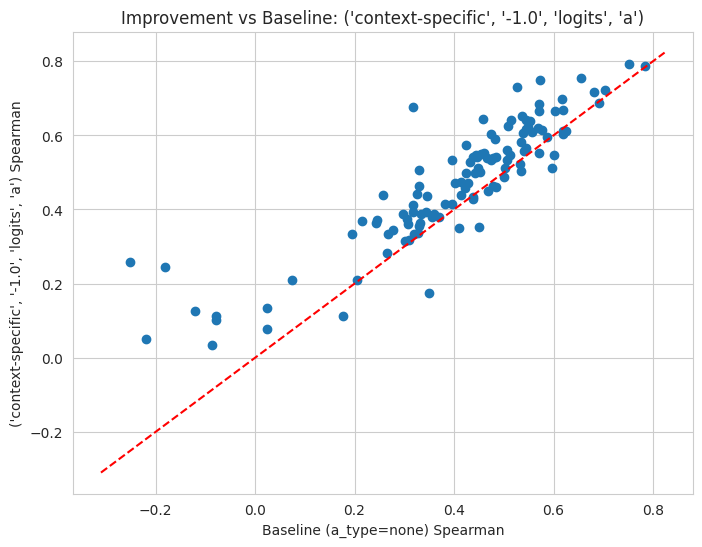

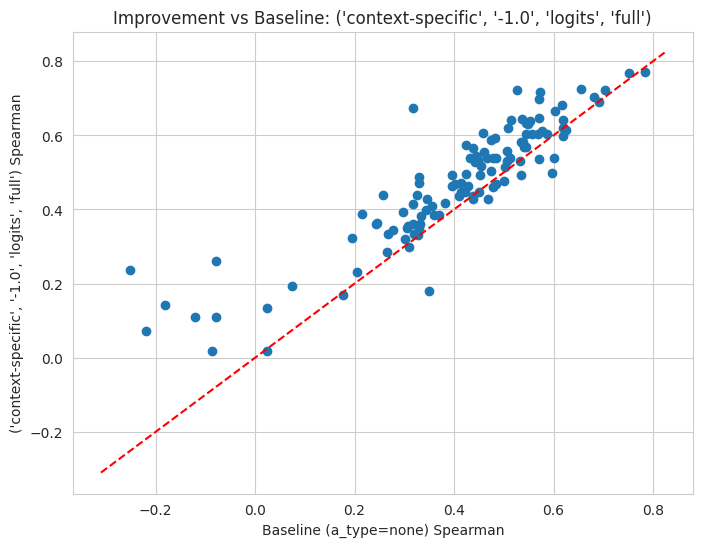

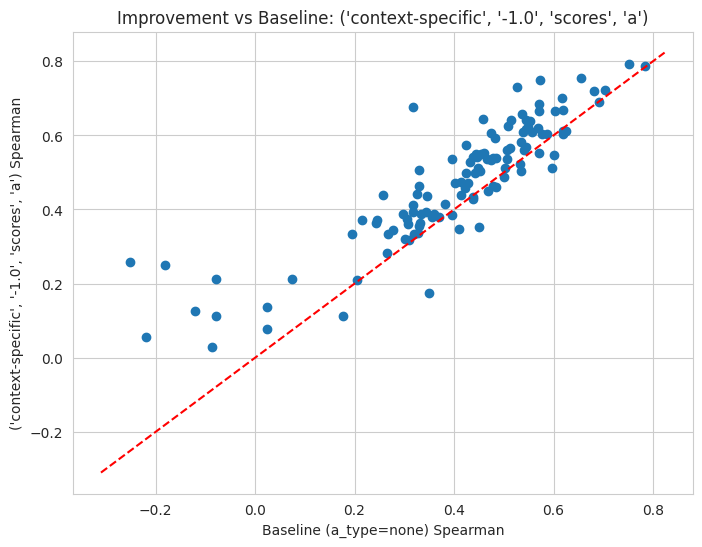

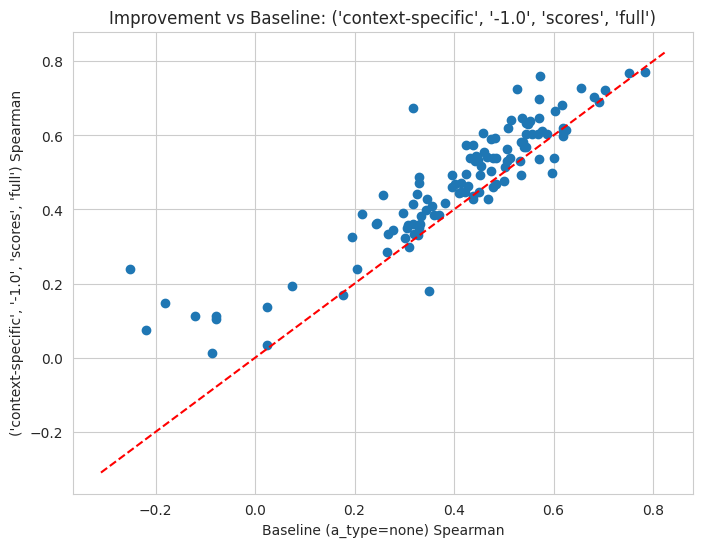

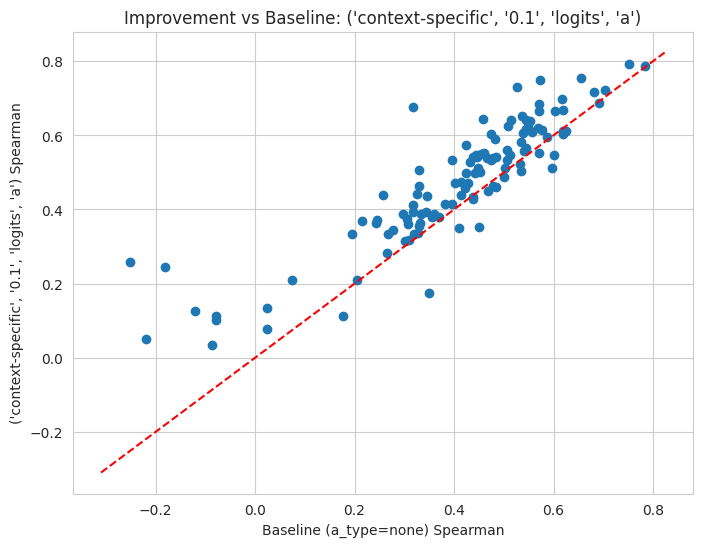

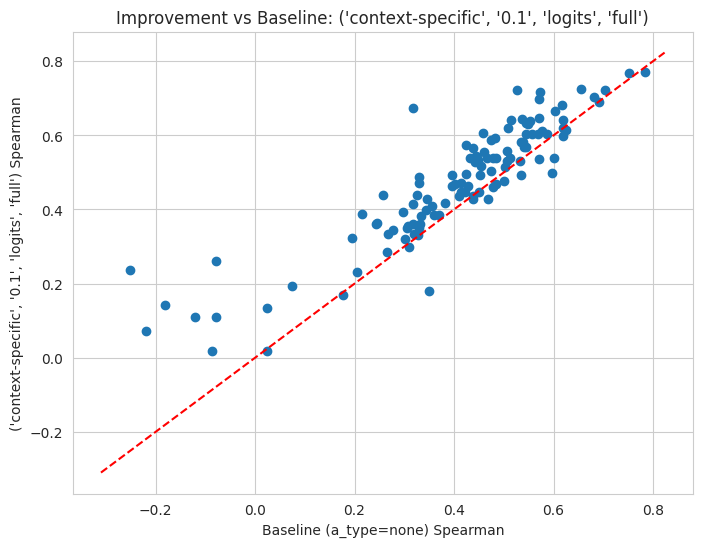

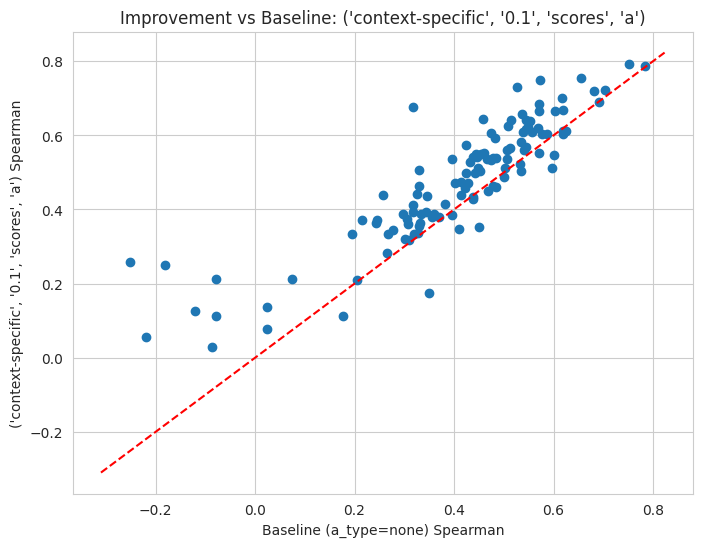

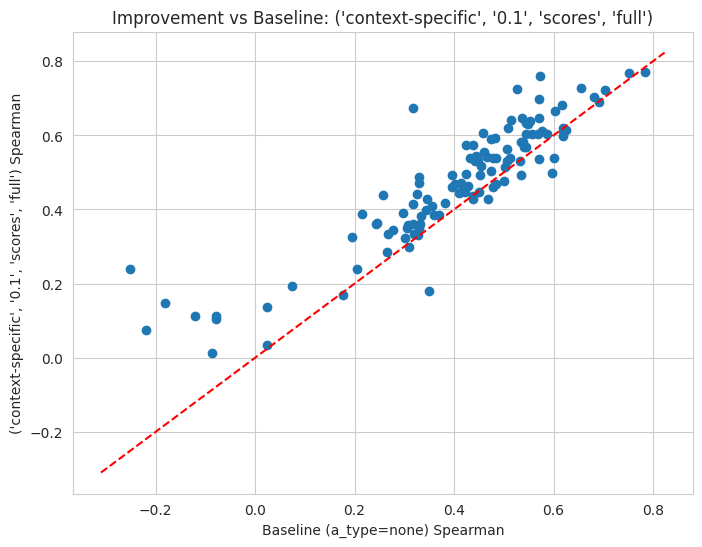

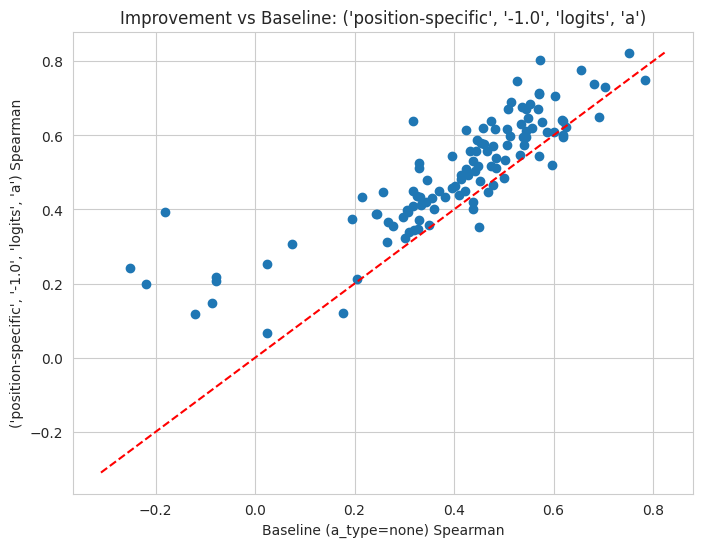

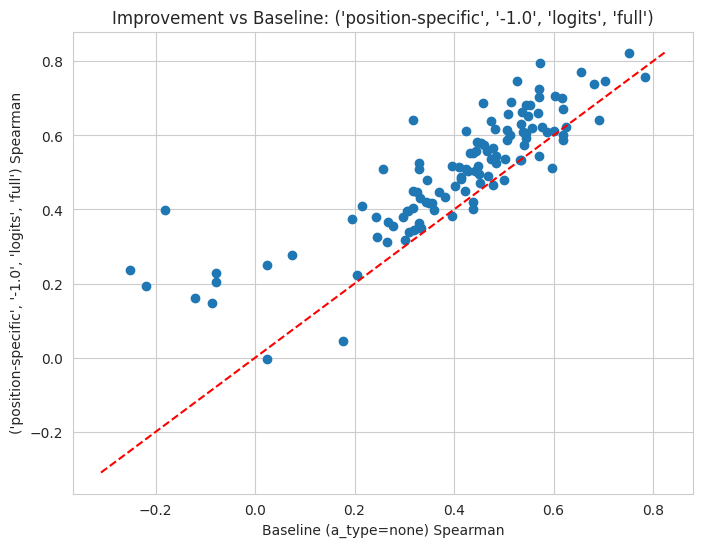

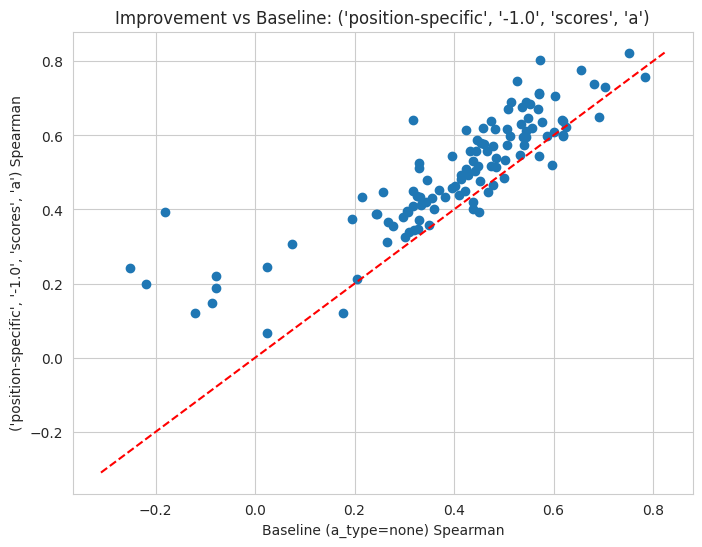

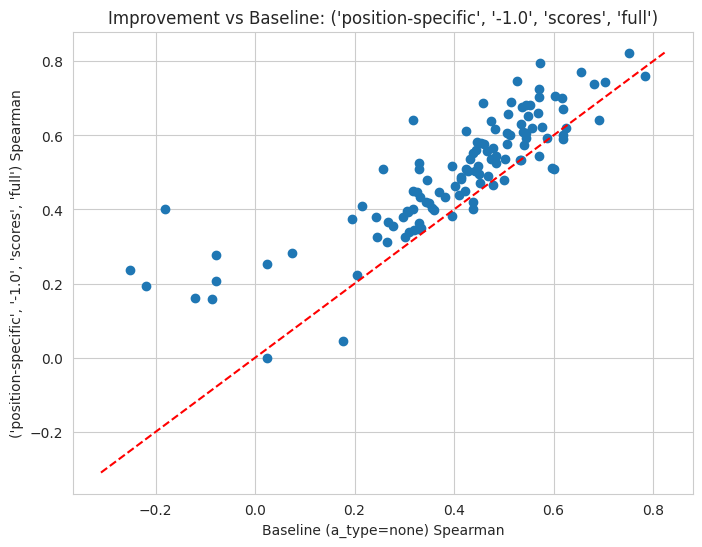

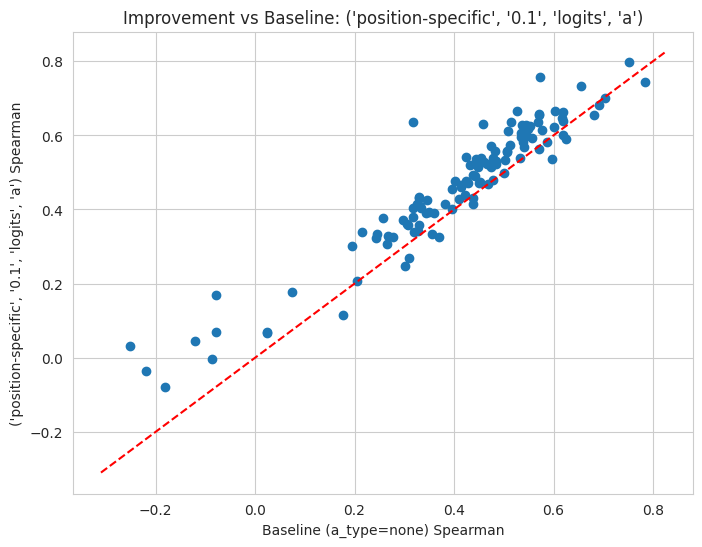

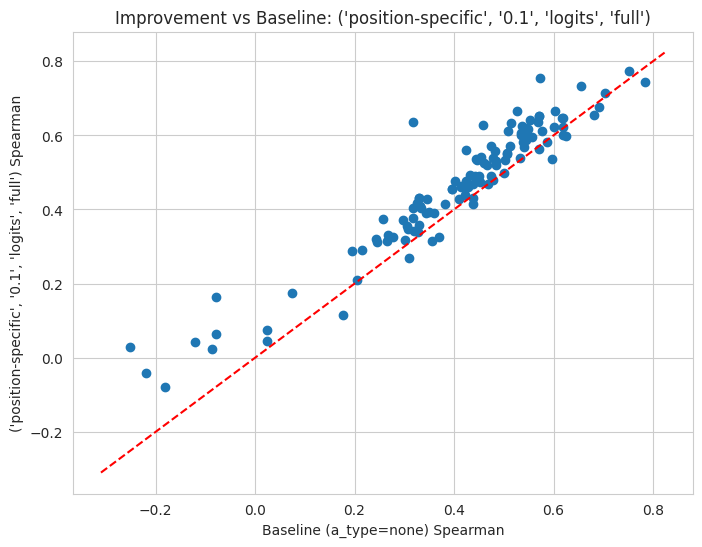

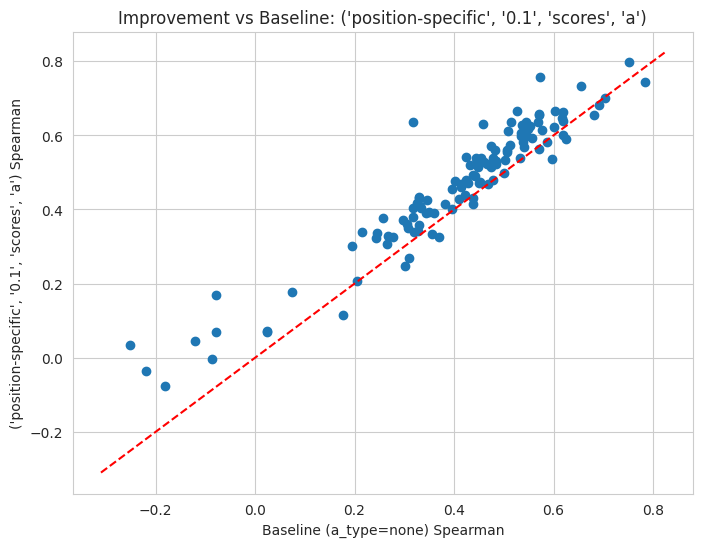

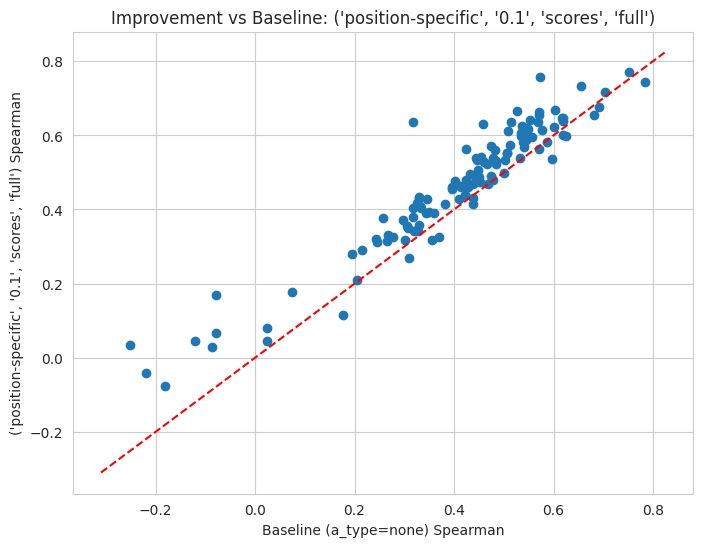

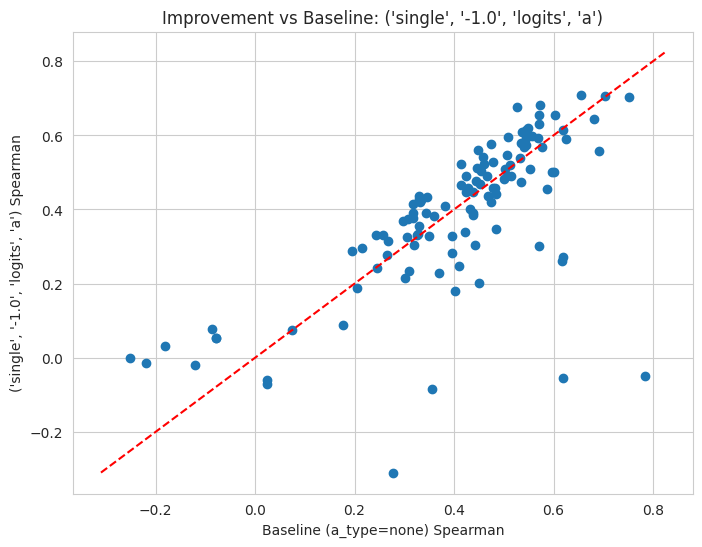

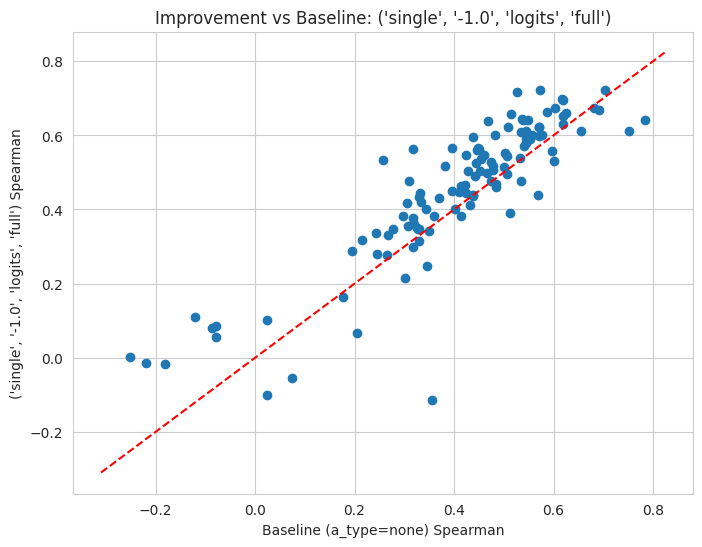

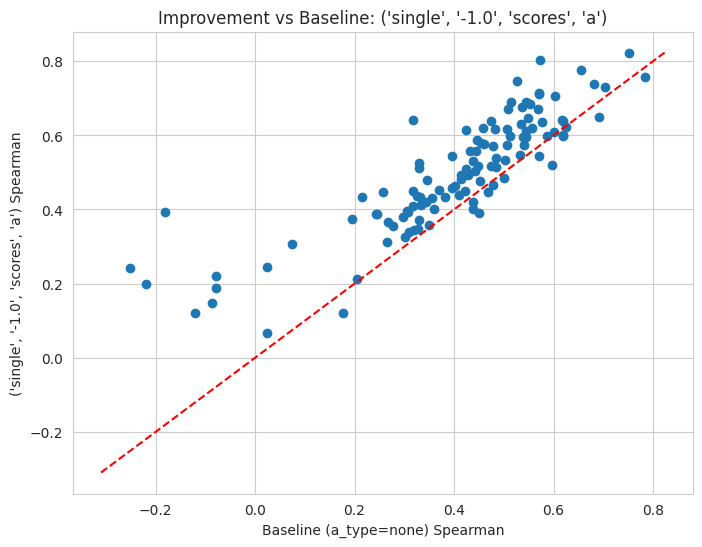

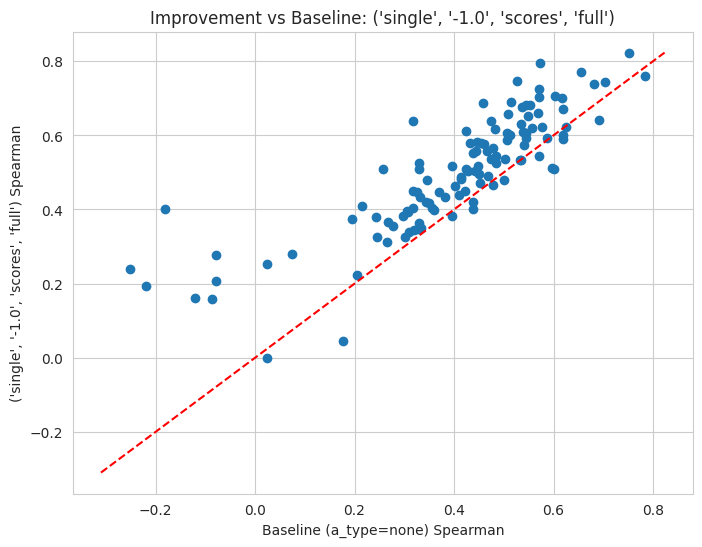

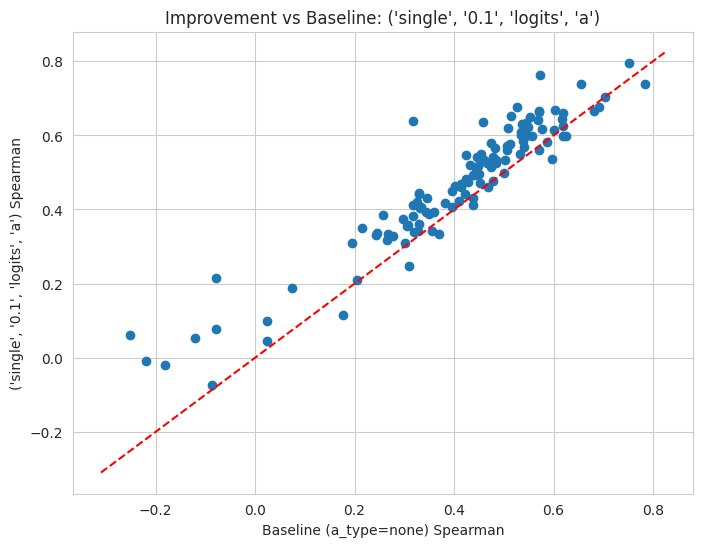

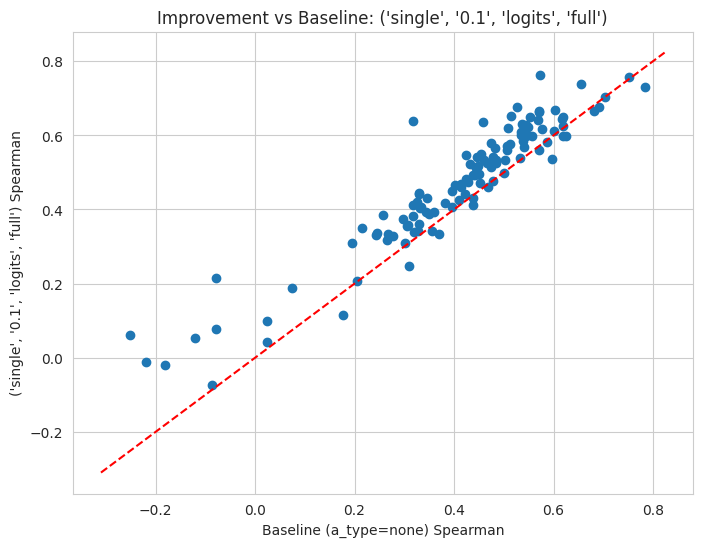

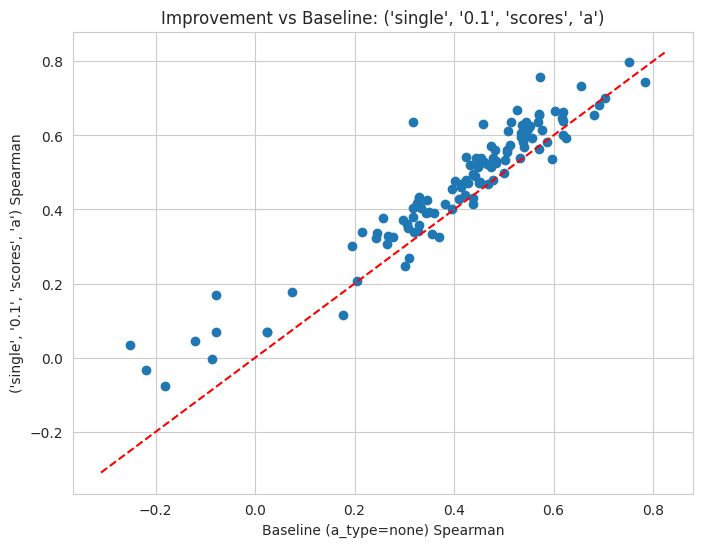

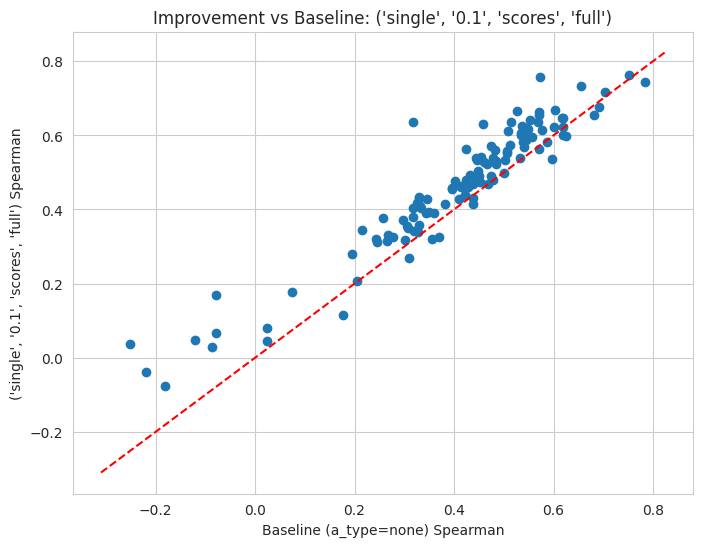

In [23]:
for col in pivot.columns:
    if col[0] == 'none': continue  
    
    plt.figure(figsize=(8, 6))
    plt.scatter(pivot['none']["0.1"], pivot[col])
    plt.plot([pivot.min().min(), pivot.max().max()], 
             [pivot.min().min(), pivot.max().max()], 'r--') 
    
    plt.xlabel('Baseline (a_type=none) Spearman')
    plt.ylabel(f'{col} Spearman')
    plt.title(f'Improvement vs Baseline: {col}')
    plt.grid(True)
    plt.show()

In [24]:
summary["train_mode"].unique()

array(['full', 'a'], dtype=object)

In [25]:
summary[summary["train_mode"] == "None"]

,dataset,a_type,a_init,combined_way,train_mode,spearman,num_mutations


In [26]:
summary[summary['a_type'] == 'None']['dataset']

Series([], Name: dataset, dtype: object)

In [27]:
summary.head()

,dataset,a_type,a_init,combined_way,train_mode,spearman,num_mutations
0,GDIA_HUMAN_Silverstein_2021,position-specific,-1.0,scores,full,0.481679,232
1,GDIA_HUMAN_Silverstein_2021,context-specific,-1.0,scores,a,0.439743,232
2,GDIA_HUMAN_Silverstein_2021,single,0.1,logits,a,0.461730,232
3,GDIA_HUMAN_Silverstein_2021,position-specific,-1.0,scores,a,0.481679,232
4,GDIA_HUMAN_Silverstein_2021,single,-1.0,logits,a,0.465621,232


In [32]:
neg1_df = summary[summary["a_init"] == "-1.0"]
pot1_df = summary[summary["a_init"] == "0.1"]

In [38]:
grouped_dataset = summary.groupby("dataset")
for dataset, group0 in grouped_dataset:
    grouped_type = group0.groupby("a_type")
    for type, group1 in grouped_type:
        if len(group1) != 8:
            print(f"{dataset}{type} has more than 8")

A0A140D2T1_ZIKV_Sourisseau_2019none has more than 8
A0A192B1T2_9HIV1_Haddox_2018none has more than 8
A0A1I9GEU1_NEIME_Kennouche_2019none has more than 8
A0A247D711_LISMN_Stadelmann_2021none has more than 8
A0A2Z5U3Z0_9INFA_Doud_2016none has more than 8
A0A2Z5U3Z0_9INFA_Wu_2014none has more than 8
A4D664_9INFA_Soh_2019none has more than 8
A4GRB6_PSEAI_Chen_2020none has more than 8
AACC1_PSEAI_Dandage_2018none has more than 8
ACE2_HUMAN_Chan_2020none has more than 8
ADRB2_HUMAN_Jones_2020none has more than 8
AICDA_HUMAN_Gajula_2014_3cyclesnone has more than 8
AMIE_PSEAE_Wrenbeck_2017none has more than 8
ANCSZ_Hobbs_2022none has more than 8
B2L11_HUMAN_Dutta_2010_binding-Mcl-1none has more than 8
BLAT_ECOLX_Deng_2012none has more than 8
BLAT_ECOLX_Firnberg_2014none has more than 8
BLAT_ECOLX_Jacquier_2013none has more than 8
BLAT_ECOLX_Stiffler_2015none has more than 8
C6KNH7_9INFA_Lee_2018none has more than 8
CALM1_HUMAN_Weile_2017none has more than 8
CASP3_HUMAN_Roychowdhury_2020none ha

In [75]:
none_df = summary[summary["a_type"] == "none"]
grouped_none = none_df.groupby("dataset")

for dataset, group in grouped_none:
    if len(group) != 2:
        print(f"{dataset} has more than 2 none")
    else:
        sr1, sr2 = group["spearman"].values
        if np.isclose(sr1, sr2):
            continue
        else:
            print(f"{dataset} unmatched non {sr1:.4f} vs {sr2:.4f}")

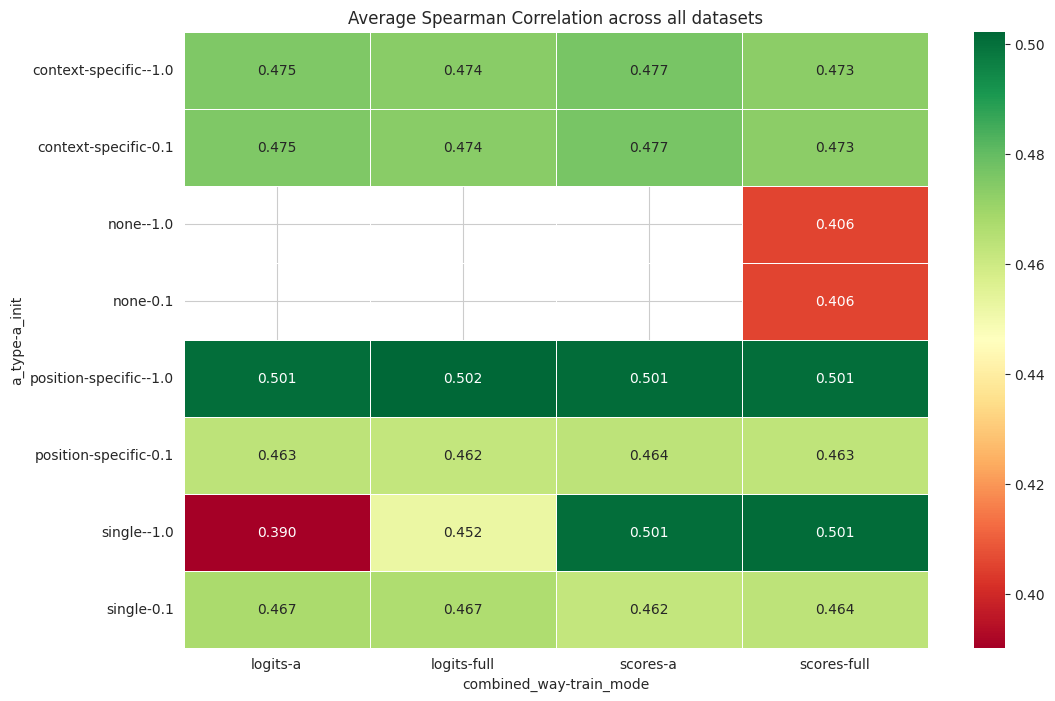

In [77]:
pivot = summary.pivot_table(
    values='spearman',
    index=['a_type', 'a_init'],
    columns=['combined_way', 'train_mode'],
    aggfunc='mean'
).round(4)

plt.figure(figsize=(12, 8))
sns.heatmap(pivot, annot=True, cmap='RdYlGn', fmt='.3f', linewidths=0.5)
plt.title('Average Spearman Correlation across all datasets')
plt.show()

In [78]:
stats = summary.groupby(['a_type', 'a_init', 'combined_way', 'train_mode'])['spearman']\
               .agg(['mean', 'std', 'max', 'count'])\
               .round(4)\
               .sort_values('mean', ascending=False)

print("=== Average performance per configuration (sorted) ===")
display(stats)

=== Average performance per configuration (sorted) ===


mean     std     max  \
a_type            a_init combined_way train_mode                           
position-specific -1.0   logits       full        0.5023  0.1587  0.8231   
single            -1.0   scores       full        0.5014  0.1575  0.8226   
position-specific -1.0   scores       a           0.5012  0.1550  0.8226   
                                      full        0.5009  0.1573  0.8226   
                         logits       a           0.5008  0.1549  0.8226   
single            -1.0   scores       a           0.5007  0.1556  0.8226   
context-specific  0.1    scores       a           0.4767  0.1652  0.7935   
                  -1.0   scores       a           0.4767  0.1652  0.7935   
                  0.1    logits       a           0.4755  0.1669  0.7935   
                  -1.0   logits       a           0.4755  0.1669  0.7935   
                  0.1    logits       full        0.4738  0.1631  0.7706   
                  -1.0   logits       full        0.4738  0.1631  0.7706   
                  0.1    scores       full        0.4731  0.1652  0.7706   
                  -1.0   scores       full        0.4731  0.1652  0.7706   
single            0.1    logits       a           0.4673  0.1768  0.7948   
                                      full        0.4667  0.1761  0.7619   
                         scores       full        0.4635  0.1773  0.7629   
position-specific 0.1    scores       a           0.4635  0.1787  0.7965   
                         logits       a           0.4634  0.1787  0.7965   
                         scores       full        0.4631  0.1781  0.7719   
single            0.1    scores       a           0.4622  0.1788  0.7965   
position-specific 0.1    logits       full        0.4621  0.1781  0.7745   
single            -1.0   logits       full        0.4522  0.1915  0.7226   
none              -1.0   scores       full        0.4056  0.1977  0.7832   
                  0.1    scores       full        0.4056  0.1977  0.7832   
single            -1.0   logits       a           0.3903  0.2035  0.7085   

                                                  count  
a_type            a_init combined_way train_mode         
position-specific -1.0   logits       full          116  
single            -1.0   scores       full          116  
position-specific -1.0   scores       a             115  
                                      full          116  
                         logits       a             115  
single            -1.0   scores       a             114  
context-specific  0.1    scores       a             116  
                  -1.0   scores       a             116  
                  0.1    logits       a             116  
                  -1.0   logits       a             116  
                  0.1    logits       full          116  
                  -1.0   logits       full          116  
                  0.1    scores       full          116  
                  -1.0   scores       full          116  
single            0.1    logits       a             116  
                                      full          116  
                         scores       full          116  
position-specific 0.1    scores       a             116  
                         logits       a             116  
                         scores       full          116  
single            0.1    scores       a             115  
position-specific 0.1    logits       full          116  
single            -1.0   logits       full          116  
none              -1.0   scores       full          116  
                  0.1    scores       full          116  
single            -1.0   logits       a             116

In [22]:
baseline = (summary[summary['a_type'] == 'none']
            .groupby('dataset')['spearman']
            .mean()  
            .rename('none_sr'))

non_none = summary[summary['a_type'] != 'none']
best_other = (non_none.groupby('dataset')['spearman']
              .max()
              .rename('best_other_sr'))

In [23]:
baseline

dataset
A0A1I9GEU1_NEIME_Kennouche_2019         0.023346
A0A247D711_LISMN_Stadelmann_2021        0.356316
A4GRB6_PSEAI_Chen_2020                  0.527284
AACC1_PSEAI_Dandage_2018                0.477571
AICDA_HUMAN_Gajula_2014_3cycles         0.349479
AMIE_PSEAE_Wrenbeck_2017                0.568856
B2L11_HUMAN_Dutta_2010_binding-Mcl-1    0.783180
BLAT_ECOLX_Deng_2012                    0.454633
BLAT_ECOLX_Firnberg_2014                0.573538
BLAT_ECOLX_Jacquier_2013                0.655040
BLAT_ECOLX_Stiffler_2015                0.680856
CALM1_HUMAN_Weile_2017                  0.204655
CASP3_HUMAN_Roychowdhury_2020           0.538014
CASP7_HUMAN_Roychowdhury_2020           0.534763
CCDB_ECOLI_Adkar_2012                   0.257643
CCDB_ECOLI_Tripathi_2016                0.296571
CCR5_HUMAN_Gill_2023                    0.329688
DYR_ECOLI_Nguyen_2023                   0.503177
DYR_ECOLI_Thompson_2019                 0.473295
ENVZ_ECOLI_Ghose_2023                   0.301170
ESTA_BACSU_N

In [24]:
best_other

dataset
A0A1I9GEU1_NEIME_Kennouche_2019         0.078779
A0A247D711_LISMN_Stadelmann_2021        0.429958
A4GRB6_PSEAI_Chen_2020                  0.747493
AACC1_PSEAI_Dandage_2018                0.572305
AICDA_HUMAN_Gajula_2014_3cycles         0.417680
AMIE_PSEAE_Wrenbeck_2017                0.672160
B2L11_HUMAN_Dutta_2010_binding-Mcl-1    0.787498
BLAT_ECOLX_Deng_2012                    0.579806
BLAT_ECOLX_Firnberg_2014                0.802468
BLAT_ECOLX_Jacquier_2013                0.776644
BLAT_ECOLX_Stiffler_2015                0.739143
CALM1_HUMAN_Weile_2017                  0.239388
CASP3_HUMAN_Roychowdhury_2020           0.641851
CASP7_HUMAN_Roychowdhury_2020           0.630791
CCDB_ECOLI_Adkar_2012                   0.533718
CCDB_ECOLI_Tripathi_2016                0.391842
CCR5_HUMAN_Gill_2023                    0.372025
DYR_ECOLI_Nguyen_2023                   0.551787
DYR_ECOLI_Thompson_2019                 0.536460
ENVZ_ECOLI_Ghose_2023                   0.326782
ESTA_BACSU_N

In [25]:
comparison = pd.concat([baseline, best_other], axis=1).reset_index()

comparison['absolute_gain']     = comparison['best_other_sr'] - comparison['none_sr']
comparison['percentage_gain_%'] = ((comparison['absolute_gain'] / comparison['none_sr']) * 100).round(2)

In [26]:
comparison = comparison.sort_values('percentage_gain_%', ascending=False).reset_index(drop=True)

In [27]:
display(comparison[['dataset', 'none_sr', 'best_other_sr', 
                    'absolute_gain', 'percentage_gain_%']])

,dataset,none_sr,best_other_sr,absolute_gain,percentage_gain_%
0,A0A1I9GEU1_NEIME_Kennouche_2019,0.023346,0.078779,0.055433,237.45
1,GLPA_HUMAN_Elazar_2016,0.317608,0.676614,0.359006,113.03
2,CCDB_ECOLI_Adkar_2012,0.257643,0.533718,0.276075,107.15
3,ESTA_BACSU_Nutschel_2020,0.214124,0.433996,0.219872,102.68
4,REV_HV1H2_Fernandes_2016,0.246110,0.387667,0.141557,57.52
5,NUD15_HUMAN_Suiter_2020,0.458757,0.686133,0.227377,49.56
6,A4GRB6_PSEAI_Chen_2020,0.527284,0.747493,0.220209,41.76
7,BLAT_ECOLX_Firnberg_2014,0.573538,0.802468,0.228930,39.92
8,RPC1_LAMBD_Li_2019_low-expression,0.437534,0.594462,0.156928,35.87
9,RASH_HUMAN_Bandaru_2017,0.431237,0.578975,0.147737,34.26


In [28]:
summary[summary["dataset"] == "R1AB_SARS2_Flynn_2022"]

,dataset,a_type,a_init,combined_way,train_mode,spearman,num_mutations
0,R1AB_SARS2_Flynn_2022,position-specific,-1.0,scores,full,0.400838,1152
1,R1AB_SARS2_Flynn_2022,context-specific,-1.0,scores,a,0.250516,1152
2,R1AB_SARS2_Flynn_2022,single,0.1,logits,a,-0.020870,1152
3,R1AB_SARS2_Flynn_2022,position-specific,-1.0,scores,a,0.393115,1152
4,R1AB_SARS2_Flynn_2022,single,-1.0,logits,a,0.030712,1152
5,R1AB_SARS2_Flynn_2022,none,0.1,scores,full,-0.181322,1152
6,R1AB_SARS2_Flynn_2022,position-specific,0.1,logits,full,-0.078525,1152
7,R1AB_SARS2_Flynn_2022,context-specific,0.1,logits,full,0.142501,1152
8,R1AB_SARS2_Flynn_2022,context-specific,0.1,logits,a,0.246110,1152
9,R1AB_SARS2_Flynn_2022,position-specific,0.1,scores,full,-0.077242,1152


In [ ]:
# method specific check
single_summary =